# Tiny Transformer Language Model

A small **decoder-only Transformer** that learns to predict the next character.
The notebook includes the text, the model, training, sampling, and the figures below.

Saved figures (character counts and the causal mask) are already in the file, so they show up when you upload it.
The loss curve and the attention map are drawn again from the trained model when you run the later cells.

Uses **PyTorch** and **matplotlib**. Nothing else is installed.

## 1. Imports and settings

The model is intentionally small so it can run on a CPU. Raise `max_steps`, `n_layer`, or `n_embd` if you have a GPU and want a stronger fit.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)

block_size = 64
batch_size = 32
n_embd = 64
n_head = 4
n_layer = 2
dropout = 0.1
max_steps = 400
learning_rate = 3e-3
eval_interval = 100
eval_iters = 20
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. Training text and character vocabulary

Each character is one token. The model sees a window of `block_size` characters and learns the distribution of the next character.

In [2]:
text = """
a tiny transformer reads one character and guesses the next.
it keeps a window of recent characters and mixes them with attention.
attention lets each position look back, never forward, so the guess stays causal.
the embedding turns a character into a vector. the position embedding says where it sits.
each block has two parts: masked self-attention, then a small feed-forward network.
residual links and layer norm keep the signal stable while the loss falls.
the loss is cross-entropy between the predicted distribution and the true next character.
after many steps the sampler can continue a prompt in the same simple style.
a river of letters flows from left to right. the model only sees the past.
once upon a line, a cat sat on a mat and watched the tiny transformer train.
the cat said: next token, please. the model said: m, a, t, and a period.
words repeat because a small corpus teaches patterns, not the whole of language.
longer data, a larger width, and more layers make the stories less repetitive.
""".strip() + "\n"

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"chars: {vocab_size}  tokens: {len(data)}  train: {len(train_data)}  val: {len(val_data)}")
print("vocab:", "".join(chars))

chars: 29  tokens: 1014  train: 912  val: 102
vocab: 
 ,-.:abcdefghiklmnoprstuvwxy


## 3. Character counts

Space and a few common letters dominate this tiny corpus. That imbalance is why the untrained model prefers frequent characters, and why the loss starts near `log(vocab size)` rather than near zero.

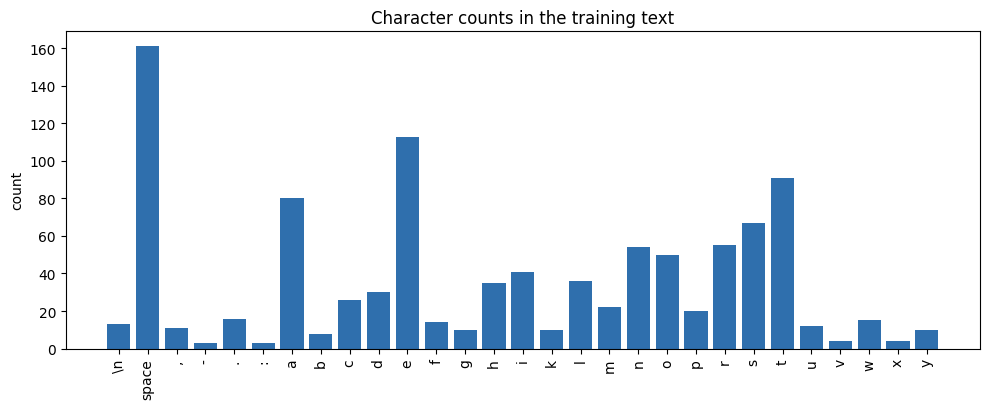

In [3]:
def show_char(ch):
    if ch == " ":
        return "space"
    if ch == "\n":
        return "\\n"
    return ch

counts = {ch: text.count(ch) for ch in chars}
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(len(chars)), [counts[ch] for ch in chars], color="#2f6fad")
ax.set_xticks(range(len(chars)))
ax.set_xticklabels([show_char(ch) for ch in chars], rotation=90)
ax.set_ylabel("count")
ax.set_title("Character counts in the training text")
fig.tight_layout()
plt.show()

## 4. Batches

`x` is a chunk of characters. `y` is the same chunk shifted one step ahead, so position `t` is trained to predict `x[t + 1]`.

In [4]:
def get_batch(split):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

## 5. Model

Causal self-attention scores each pair of positions, then sets future positions to `-inf` before the softmax. A Transformer block is attention plus a two-layer MLP, each wrapped with pre-norm and a residual add. The language-model head maps the final hidden state to logits over the character vocabulary.

Each attention layer keeps `last_attn` so a later cell can plot it.

In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert n_embd % n_head == 0
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer("mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x):
        b, t, c = x.shape
        q, k, v = self.qkv(x).split(c, dim=2)
        q = q.view(b, t, n_head, self.head_dim).transpose(1, 2)
        k = k.view(b, t, n_head, self.head_dim).transpose(1, 2)
        v = v.view(b, t, n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :t, :t] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        self.last_attn = att.detach()
        att = self.attn_drop(att)
        y = (att @ v).transpose(1, 2).contiguous().view(b, t, c)
        return self.resid_drop(self.proj(y))


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention()
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = MLP()

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.shape
        if t > block_size:
            raise ValueError(f"sequence length {t} exceeds block_size {block_size}")
        pos = torch.arange(t, device=idx.device)
        x = self.drop(self.token_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits = logits.masked_fill(logits < values[:, [-1]], float("-inf"))
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx


model = TinyTransformerLM().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

parameters: 106,048


## 6. Causal mask

A query at row `i` may attend only to keys at columns `0 ... i`. Cells above the diagonal stay hidden, so the model cannot look at future characters.

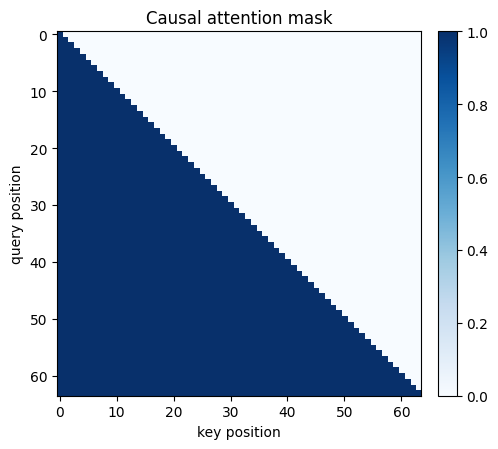

In [6]:
mask = torch.tril(torch.ones(block_size, block_size))
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(mask, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
ax.set_title("Causal attention mask")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 7. Training

AdamW minimizes next-character cross-entropy. Every `eval_interval` steps the notebook records train and validation loss with dropout turned off. The next cell plots those lists.

In [7]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    losses = {}
    for split in ("train", "val"):
        total = 0.0
        for _ in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            total += loss.item()
        losses[split] = total / eval_iters
    model.train()
    return losses


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
steps_logged = []
train_losses = []
val_losses = []

for step in range(max_steps):
    if step % eval_interval == 0 or step == max_steps - 1:
        losses = estimate_loss()
        steps_logged.append(step)
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        print(f"step {step:4d}  train {losses['train']:.3f}  val {losses['val']:.3f}")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step    0  train 3.391  val 3.405
step  100  train 1.909  val 2.852
step  200  train 0.739  val 3.847
step  300  train 0.279  val 4.662
step  399  train 0.182  val 4.954


## 8. Loss curve

Train and validation loss should fall together on this small text. A wide gap means the model is memorizing the training split.

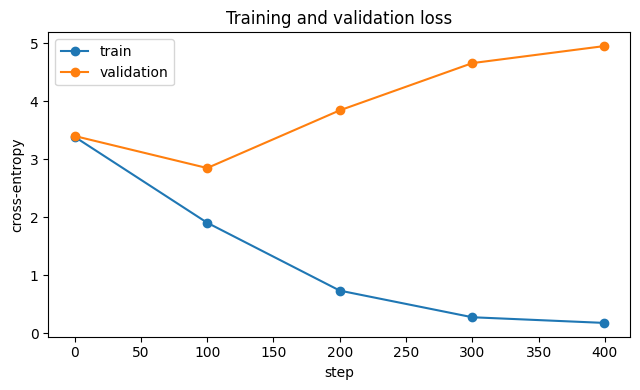

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(steps_logged, train_losses, marker="o", label="train")
ax.plot(steps_logged, val_losses, marker="o", label="validation")
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy")
ax.set_title("Training and validation loss")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Sample text

Generation starts from a prompt and appends one character at a time. `temperature` below 1 makes the sample sharper. `top_k` keeps only the most likely characters at each step.

In [9]:
model.eval()
prompt = "once upon a line, "
start = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
out = model.generate(start, max_new_tokens=300, temperature=0.8, top_k=10)
print(decode(out[0].tolist()))

once upon a line, a cat sat sat on a mat and watched the tiny trainsformer train.
the cat said: next t token, ple. the model said: m, t, and period.
words repeat because small corpus teaches te posion embeddding says where it sits.
each block has two parts: masked self-atention, sken a smal fed-forward netwark.
resid


## 10. Attention and next-character probabilities

The heatmap is the last layer's attention on a short prompt, averaged over heads. Darker blue means a query (row) put more weight on that key (column). The bars are the model's distribution for the character that would come next.

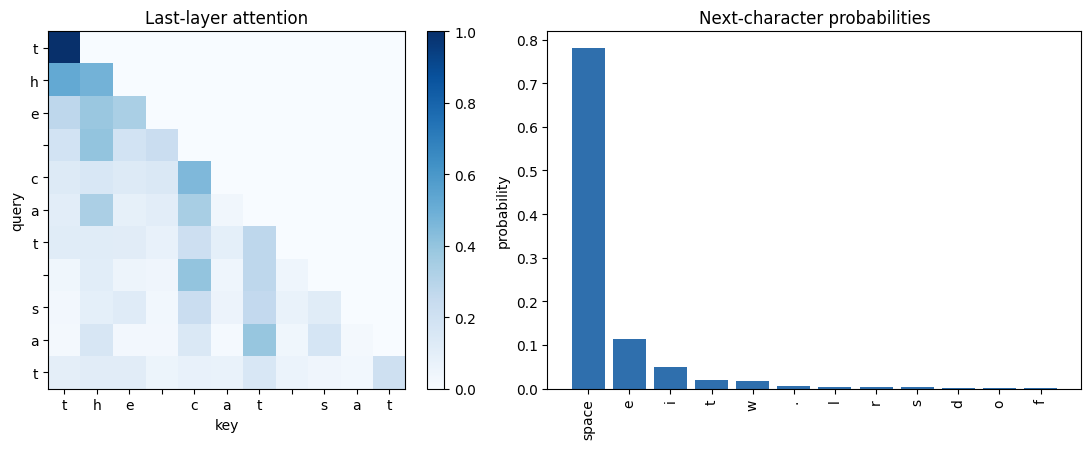

In [10]:
probe = "the cat sat"
probe_ids = torch.tensor([encode(probe)], dtype=torch.long, device=device)
with torch.no_grad():
    logits, _ = model(probe_ids)
attn = model.blocks[-1].attn.last_attn[0].mean(dim=0).cpu()
probs = torch.softmax(logits[0, -1], dim=-1)
top_p, top_i = torch.topk(probs, k=12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
im = axes[0].imshow(attn, cmap="Blues", interpolation="nearest")
axes[0].set_xticks(range(len(probe)))
axes[0].set_yticks(range(len(probe)))
axes[0].set_xticklabels(list(probe))
axes[0].set_yticklabels(list(probe))
axes[0].set_xlabel("key")
axes[0].set_ylabel("query")
axes[0].set_title("Last-layer attention")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

tick_labels = [show_char(itos[int(i)]) for i in top_i.tolist()]
axes[1].bar(tick_labels, top_p.tolist(), color="#2f6fad")
axes[1].set_ylabel("probability")
axes[1].set_title("Next-character probabilities")
axes[1].tick_params(axis="x", rotation=90)
fig.tight_layout()
plt.show()

## 11. What this shows

On a few hundred characters the model mostly memorizes local phrases. That is expected. The same code is the core of a larger language model: swap the character tokenizer for a subword tokenizer, train on a much larger corpus, and scale `n_layer`, `n_embd`, `n_head`, and `block_size`.